# NAS-Bench-201 — Multi-Objective Search Pipeline (Study 3)

This notebook runs all six algorithms on **NAS-Bench-201** with two simultaneous objectives:

- **f₁ = 1 − test_acc** (minimise → maximise accuracy)
- **f₂ = normalised FLOPs** (minimise → fewer operations)

### Algorithms

| Algorithm | Strategy | Library |
|-----------|----------|---------|
| **NSGA-II** | Native Pareto selection | pymoo |
| **GA** | Scalarised weighted sum, α sweep | mealpy |
| **SADE** | Scalarised weighted sum, α sweep | mealpy |
| **GWO** | Scalarised weighted sum, α sweep | mealpy |
| **AIW-PSO** | Scalarised weighted sum, α sweep | mealpy |
| **BO** | Scalarised weighted sum, α sweep | bayesian-optimization |

For scalarised algorithms the fitness is:
$$\text{fitness} = \alpha \cdot f_1 + (1-\alpha) \cdot f_2$$
The notebook runs each algorithm once per α value (9 values) × per seed.
Aggregating all runs gives the Pareto front approximation for each algorithm.

Performance is measured via the **hypervolume indicator (HV)**.

## Setup checklist
1. `pip install nats_bench pymoo bayesian-optimization mealpy`
2. Download and extract `NATS-tss-v1_0-3ffb9-simple.tar` from https://github.com/D-X-Y/NATS-Bench
3. Set `NAS_PATH` below to the extracted directory.

## 1. Imports and path setup

In [ ]:
import os, sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
from datetime import datetime as _dt
ROOT = Path.cwd()

# Point this at the *uncompressed* NAS-Bench-201 directory.
# IMPORTANT: do NOT point at a .tar file — extract it first.
NAS_PATH = ROOT / 'utils' / 'nas_records' / 'NATS-tss-v1_0' / 'NATS-tss-v1_0'

# Add code root to path
if (ROOT / 'utils').exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'utils').exists():
    sys.path.insert(0, str(ROOT.parent))

from utils.nas import getApi, N_ARCHS, queryArchitecture
from utils.nas_mo import (
    computeFlopsRange,
    computeTrueParetoFront,
    computeHypervolume,
    runGDE3NASSearch,
    runQEHVINASSearch,
    runNSGAIINASSearch,
    runMONASScalarized,
    runBOMONASScalarized,
    runBOMONASScalarizedSweep,
    makeScalarizedObjective,
    _normFlops,
    ALPHA_SWEEP,
    REF_POINT,
    N_OPS,
    N_EDGES,
)

print('Imports OK')
print('ROOT    :', ROOT)
print('NAS_PATH:', NAS_PATH)

Imports OK
ROOT    : c:\Users\ruben\repos\tese-mestrado\code
NAS_PATH: c:\Users\ruben\repos\tese-mestrado\code\utils\nas_records\NATS-tss-v1_0\NATS-tss-v1_0


## 2. Configuration

In [ ]:
# ── Datasets ──────────────────────────────────────────────────────────────
DATASETS_USED = ['cifar10', 'cifar100', 'ImageNet16-120']
HP            = '200'          # full-epoch accuracy in NAS-Bench-201

# ── Search budget ─────────────────────────────────────────────────────────
# Must match Study 2 so comparisons are fair.
N_GENERATIONS = 50
POP_SIZE      = 20
# Total queries per single run = (N_GENERATIONS + 1) * POP_SIZE = 1020
N_QUERIES = (N_GENERATIONS + 1) * POP_SIZE

# ── Scalarisation sweep ───────────────────────────────────────────────────
# ALPHA_SWEEP is imported from nas_mo: [0.1, 0.2, ..., 0.9, 1.0].
# alpha = 1.0 puts zero weight on FLOPs, so the high-accuracy endpoint of the
# front is optimized without a cost penalty.
#
# PROTOCOL: the search is scored on VALIDATION accuracy and the TEST accuracy
# is read only for the architecture each run finally returns. On CIFAR-10 the
# validation signal comes from the 'cifar10-valid' entry (trained on 25k,
# scored on the held-out 25k) because the plain 'cifar10' entry is trained on
# the full 50k and has no honest validation split. The exhaustive upper bound
# and true Pareto front stay on TEST: they are the yardstick, never a signal
# the search may consult.
# Each algorithm is run once per alpha per seed.
# Total per algorithm per dataset = len(ALPHA_SWEEP) × len(SEEDS) runs.
SEEDS = [0, 1, 2]       # 3 independent seeds

# GDE3 — native multi-objective Differential Evolution.
GDE3_CR      = 0.9
GDE3_F       = 0.5
GDE3_VARIANT = 'DE/rand/1/bin'

# qEHVI — native multi-objective Bayesian optimisation (needs botorch).
# Total queries = QEHVI_INIT + QEHVI_N_ITER * QEHVI_BATCH. Spend the budget
# through the batch q (=5) rather than 1000 single-point GP refits.
QEHVI_INIT   = POP_SIZE                              # 20
QEHVI_BATCH  = 5
QEHVI_N_ITER = (N_QUERIES - QEHVI_INIT) // QEHVI_BATCH   # 200  -> 20 + 200*5 = 1020
QEHVI_MC     = 128

# ── NSGA-II ───────────────────────────────────────────────────────────────
# Runs once per seed (native multi-objective, no alpha sweep needed).
NSGA2_SEEDS = SEEDS

# ── BO ────────────────────────────────────────────────────────────────────
BO_INIT_POINTS = POP_SIZE          # random initialisation
BO_N_ITER      = N_GENERATIONS * POP_SIZE   # BO-guided iterations
BO_XI          = 0.01

# ── Output ────────────────────────────────────────────────────────────────
RESULTS_ROOT = ROOT / 'colab' / 'results'
if not RESULTS_ROOT.exists():
    RESULTS_ROOT = ROOT.parent / 'code' / 'colab' / 'results'
MO_ROOT = RESULTS_ROOT / 'MO_NAS_2'
MO_ROOT.mkdir(parents=True, exist_ok=True)

print('SEEDS          :', SEEDS)
print('ALPHA_SWEEP    :', ALPHA_SWEEP)
print('search signal  : valid_acc   |  reported: test_acc')
print('N_QUERIES/run  :', N_QUERIES)
print('Datasets       :', DATASETS_USED)
print('Output root    :', MO_ROOT)

SEEDS          : [0, 1, 2]
ALPHA_SWEEP    : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N_QUERIES/run  : 1020
Datasets       : ['cifar10', 'cifar100', 'ImageNet16-120']
Output root    : c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS


## 3. Load NAS-Bench-201 API

In [4]:
nas_path = Path(NAS_PATH)

if not nas_path.exists():
    raise FileNotFoundError(
        f'NAS_PATH does not exist: {nas_path}\n'
        f'  Download NATS-tss-v1_0-3ffb9-simple.tar from '
        f'https://github.com/D-X-Y/NATS-Bench and extract it.'
    )
if nas_path.suffix.lower() == '.tar':
    raise ValueError(
        f'NAS_PATH points at a .tar archive: {nas_path}\n'
        f'  nats_bench needs the *extracted* directory, not the tarball.'
    )
if nas_path.is_dir() and not any(nas_path.iterdir()):
    raise ValueError(f'NAS_PATH is an empty directory: {nas_path}')

print(f'NAS_PATH OK: {nas_path}')
print('Loading the NAS-Bench-201 API (≈30 s first time)…')

api = getApi(file_path=str(nas_path))
print(f'API loaded.  Total architectures: {N_ARCHS}')

NAS_PATH OK: c:\Users\ruben\repos\tese-mestrado\code\utils\nas_records\NATS-tss-v1_0\NATS-tss-v1_0
Loading the NAS-Bench-201 API (≈30 s first time)…
API loaded.  Total architectures: 15625


## 4. Pre-compute FLOPs range and True Pareto Front

Both are obtained by exhaustive enumeration of all 15 625 architectures.
This takes a few minutes but runs only once per session (results are cached
in-process for FLOPs range; the true Pareto front is also saved to disk).

In [6]:
# The FLOPs range and the exhaustive Pareto front depend only on the benchmark,
# not on any optimizer, so they are computed once and reused. Three sources are
# tried in order:
#
#   1. flops/flops_range_<ds>_hp<hp>.json + flops/true_front_<ds>_hp<hp>.json
#      — what computeFlopsRange / computeTrueParetoFront write.
#   2. true_front_<ds>.json — the copy aggregate_mo_nas.py reads. It has no
#      range file beside it, but norm_flops = (flops - fmin) / (fmax - fmin),
#      so two points with different cost recover fmin and fmax exactly.
#   3. Enumerate all 15,625 cells (minutes per dataset).
#
# The reference front stays on TEST accuracy (computeTrueParetoFront defaults
# to fitness_key='test_acc'): it is the yardstick every method is measured
# against, never a signal the search may consult.
CACHE_DIR = MO_ROOT / 'flops'
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _flopsRangeFromFront(front):
    """Recover (fmin, fmax) from a front's flops_M / norm_flops pairs."""
    a = front[0]
    b = next((p for p in front
              if abs(p['norm_flops'] - a['norm_flops']) > 1e-9), None)
    if b is None:
        return None
    span = ((a['flops_M'] - b['flops_M'])
            / (a['norm_flops'] - b['norm_flops']))
    fmin = a['flops_M'] - a['norm_flops'] * span
    return fmin, fmin + span


flops_ranges = {}
true_fronts  = {}

for dataset in DATASETS_USED:
    print(f'\n─── {dataset} ───')
    fr_path  = CACHE_DIR / f'flops_range_{dataset}_hp{HP}.json'
    tf_path  = CACHE_DIR / f'true_front_{dataset}_hp{HP}.json'
    agg_path = MO_ROOT / f'true_front_{dataset}.json'

    t0 = time.time()
    fmin = fmax = tf = None

    # 1. the canonical pair
    if fr_path.exists() and tf_path.exists():
        with open(fr_path) as f:
            d = json.load(f)
        fmin, fmax = d['min_flops_M'], d['max_flops_M']
        with open(tf_path) as f:
            tf = json.load(f)
        print(f'  loaded {fr_path.name} + {tf_path.name}')

    # 2. the aggregate copy, with the range recovered from it
    elif agg_path.exists():
        with open(agg_path) as f:
            tf = json.load(f)
        rng = _flopsRangeFromFront(tf) if tf else None
        if rng is None and fr_path.exists():
            with open(fr_path) as f:
                d = json.load(f)
            rng = (d['min_flops_M'], d['max_flops_M'])
        if rng is None:
            tf = None                     # unusable, fall through to compute
        else:
            fmin, fmax = rng
            print(f'  loaded {agg_path.name} '
                  f'(FLOPs range recovered from norm_flops)')

    # 3. enumerate
    if tf is None:
        print('  no cache — enumerating 15,625 cells, this takes a few minutes')
        fmin, fmax = computeFlopsRange(
            api, dataset=dataset, hp=HP,
            save_dir=str(CACHE_DIR), verbose=True)
        tf = computeTrueParetoFront(
            api, dataset=dataset, hp=HP,
            save_dir=str(CACHE_DIR), verbose=True)
        print(f'  computed and cached in {time.time() - t0:.0f}s')

    # Fail loudly here rather than producing silently wrong hypervolumes later.
    assert tf, f'{dataset}: true front is empty'
    absent = {'f1', 'f2', 'test_acc', 'flops_M', 'norm_flops'} - set(tf[0])
    assert not absent, f'{dataset}: front entries missing {sorted(absent)}'
    assert fmax > fmin, f'{dataset}: bad FLOPs range ({fmin}, {fmax})'

    flops_ranges[dataset] = (fmin, fmax)
    true_fronts[dataset]  = tf

    # Keep both cache locations populated for the next run and for
    # aggregate_mo_nas.py; rewrite only when the content actually differs.
    for path, payload in ((tf_path, tf), (agg_path, tf)):
        stale = True
        if path.exists():
            try:
                stale = json.loads(path.read_text()) != payload
            except Exception:
                stale = True
        if stale:
            path.parent.mkdir(parents=True, exist_ok=True)
            with open(path, 'w') as f:
                json.dump(payload, f, indent=2)
            print(f'  wrote {path.name}')
    if not fr_path.exists():
        with open(fr_path, 'w') as f:
            json.dump({'dataset': dataset, 'hp': HP, 'min_flops_M': fmin,
                       'max_flops_M': fmax, 'n_archs': N_ARCHS}, f, indent=2)
        print(f'  wrote {fr_path.name}')

    tf_hv = computeHypervolume([[p['f1'], p['f2']] for p in tf])
    print(f'  |True front| = {len(tf)}  HV* = {tf_hv:.6f}  '
          f'FLOPs = [{fmin:.2f}, {fmax:.2f}]  '
          f'best test acc = {max(t["test_acc"] for t in tf):.4f}')


─── cifar10 ───
  Loading FLOPs range from c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\flops\flops_range_cifar10_hp200.json
  Loading true Pareto front from c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\flops\true_front_cifar10_hp200.json
  |True front| = 17  HV = 1.140140

─── cifar100 ───
  Loading FLOPs range from c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\flops\flops_range_cifar100_hp200.json
  Loading true Pareto front from c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\flops\true_front_cifar100_hp200.json
  |True front| = 13  HV = 0.900813

─── ImageNet16-120 ───
  Loading FLOPs range from c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\flops\flops_range_ImageNet16-120_hp200.json
  Loading true Pareto front from c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\flops\true_front_ImageNet16-120_hp200.json
  |True front| = 13  HV = 0.610671


## 5. GA — Scalarised sweep

Runs the Genetic Algorithm once per (alpha, seed) pair.
Sweeping 9 alpha values × 3 seeds = 27 runs per dataset.

In [ ]:
ga_summary = []

for dataset in DATASETS_USED:
    print(f'\n{"#"*70}')
    print(f'#  GA  —  {dataset}')
    print(f'{"#"*70}')

    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'ga' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in SEEDS:
        seed_pts = []
        for i, alpha in enumerate(ALPHA_SWEEP):
            pt, run = runMONASScalarized(
                algorithm     = 'GA',
                api           = api,
                dataset       = dataset,
                hp            = HP,
                alpha         = alpha,
                n_generations = N_GENERATIONS,
                pop_size      = POP_SIZE,
                seed          = seed * 100 + i,
                flops_min     = fmin,
                flops_max     = fmax,
                results_dir   = str(out_dir),
                verbose       = False,
            )
            seed_pts.append(pt)

        seed_hv = computeHypervolume([[p['f1'], p['f2']] for p in seed_pts])
        tf_hv   = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        ga_summary.append({
            'dataset':   dataset,
            'algorithm': 'GA',
            'seed':      seed,
            'hv':        seed_hv,
            'hv_gap':    tf_hv - seed_hv,
            'best_acc':  max(p['test_acc'] for p in seed_pts),
            'min_flops': min(p['flops_M']  for p in seed_pts),
        })

df_ga = pd.DataFrame(ga_summary)
print('\nGA summary:')
print(df_ga.groupby('dataset')[['hv', 'best_acc']].agg(['mean', 'std']).round(4).to_string())

## 6. SADE — Scalarised sweep

In [ ]:
sade_summary = []

for dataset in DATASETS_USED:
    print(f'\n{"#"*70}')
    print(f'#  SADE  —  {dataset}')
    print(f'{"#"*70}')

    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'sade' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in SEEDS:
        seed_pts = []
        for i, alpha in enumerate(ALPHA_SWEEP):
            pt, run = runMONASScalarized(
                algorithm     = 'SADE',
                api           = api,
                dataset       = dataset,
                hp            = HP,
                alpha         = alpha,
                n_generations = N_GENERATIONS,
                pop_size      = POP_SIZE,
                seed          = seed * 100 + i,
                flops_min     = fmin,
                flops_max     = fmax,
                results_dir   = str(out_dir),
                verbose       = False,
            )
            seed_pts.append(pt)

        seed_hv = computeHypervolume([[p['f1'], p['f2']] for p in seed_pts])
        tf_hv   = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        sade_summary.append({
            'dataset':   dataset,
            'algorithm': 'SADE',
            'seed':      seed,
            'hv':        seed_hv,
            'hv_gap':    tf_hv - seed_hv,
            'best_acc':  max(p['test_acc'] for p in seed_pts),
            'min_flops': min(p['flops_M']  for p in seed_pts),
        })

df_sade = pd.DataFrame(sade_summary)
print('\nSADE summary:')
print(df_sade.groupby('dataset')[['hv', 'best_acc']].agg(['mean', 'std']).round(4).to_string())

## 7. GWO — Scalarised sweep

In [ ]:
gwo_summary = []

for dataset in DATASETS_USED:
    print(f'\n{"#"*70}')
    print(f'#  GWO  —  {dataset}')
    print(f'{"#"*70}')

    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'gwo' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in SEEDS:
        seed_pts = []
        for i, alpha in enumerate(ALPHA_SWEEP):
            pt, run = runMONASScalarized(
                algorithm     = 'GWO',
                api           = api,
                dataset       = dataset,
                hp            = HP,
                alpha         = alpha,
                n_generations = N_GENERATIONS,
                pop_size      = POP_SIZE,
                seed          = seed * 100 + i,
                flops_min     = fmin,
                flops_max     = fmax,
                results_dir   = str(out_dir),
                verbose       = False,
            )
            seed_pts.append(pt)

        seed_hv = computeHypervolume([[p['f1'], p['f2']] for p in seed_pts])
        tf_hv   = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        gwo_summary.append({
            'dataset':   dataset,
            'algorithm': 'GWO',
            'seed':      seed,
            'hv':        seed_hv,
            'hv_gap':    tf_hv - seed_hv,
            'best_acc':  max(p['test_acc'] for p in seed_pts),
            'min_flops': min(p['flops_M']  for p in seed_pts),
        })

df_gwo = pd.DataFrame(gwo_summary)
print('\nGWO summary:')
print(df_gwo.groupby('dataset')[['hv', 'best_acc']].agg(['mean', 'std']).round(4).to_string())

## 8. AIW-PSO — Scalarised sweep

In [ ]:
pso_summary = []

for dataset in DATASETS_USED:
    print(f'\n{"#"*70}')
    print(f'#  AIW-PSO  —  {dataset}')
    print(f'{"#"*70}')

    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'aiw_pso' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in SEEDS:
        seed_pts = []
        for i, alpha in enumerate(ALPHA_SWEEP):
            pt, run = runMONASScalarized(
                algorithm     = 'AIW_PSO',
                api           = api,
                dataset       = dataset,
                hp            = HP,
                alpha         = alpha,
                n_generations = N_GENERATIONS,
                pop_size      = POP_SIZE,
                seed          = seed * 100 + i,
                flops_min     = fmin,
                flops_max     = fmax,
                results_dir   = str(out_dir),
                verbose       = False,
            )
            seed_pts.append(pt)

        seed_hv = computeHypervolume([[p['f1'], p['f2']] for p in seed_pts])
        tf_hv   = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        pso_summary.append({
            'dataset':   dataset,
            'algorithm': 'AIW_PSO',
            'seed':      seed,
            'hv':        seed_hv,
            'hv_gap':    tf_hv - seed_hv,
            'best_acc':  max(p['test_acc'] for p in seed_pts),
            'min_flops': min(p['flops_M']  for p in seed_pts),
        })

df_pso = pd.DataFrame(pso_summary)
print('\nAIW-PSO summary:')
print(df_pso.groupby('dataset')[['hv', 'best_acc']].agg(['mean', 'std']).round(4).to_string())

## 9. BO — Scalarised sweep

Bayesian Optimisation with Expected Improvement, one run per (alpha, seed).
Budget per run = `BO_INIT_POINTS + BO_N_ITER = N_QUERIES`, matching the EAs.

In [ ]:
bo_summary = []

for dataset in DATASETS_USED:
    print(f'\n{"#"*70}')
    print(f'#  BO  —  {dataset}')
    print(f'{"#"*70}')

    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'bo' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in SEEDS:
        seed_pts = []
        for i, alpha in enumerate(ALPHA_SWEEP):
            pt, _ = runBOMONASScalarized(
                api         = api,
                dataset     = dataset,
                hp          = HP,
                alpha       = alpha,
                n_iter      = BO_N_ITER,
                init_points = BO_INIT_POINTS,
                xi          = BO_XI,
                seed        = seed * 100 + i,
                flops_min   = fmin,
                flops_max   = fmax,
                results_dir = str(out_dir),
                verbose     = False,
            )
            seed_pts.append(pt)

        seed_hv = computeHypervolume([[p['f1'], p['f2']] for p in seed_pts])
        tf_hv   = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        bo_summary.append({
            'dataset':   dataset,
            'algorithm': 'BO',
            'seed':      seed,
            'hv':        seed_hv,
            'hv_gap':    tf_hv - seed_hv,
            'best_acc':  max(p['test_acc'] for p in seed_pts),
            'min_flops': min(p['flops_M']  for p in seed_pts),
        })

df_bo = pd.DataFrame(bo_summary)
print('\nBO summary:')
print(df_bo.groupby('dataset')[['hv', 'best_acc']].agg(['mean', 'std']).round(4).to_string())

## 10. NSGA-II

Native multi-objective EA. Runs once per seed per dataset.
Produces a Pareto front approximation and a per-generation HV history.

In [ ]:
nsga2_summary = []

for dataset in DATASETS_USED:
    print(f'\n{"#"*70}')
    print(f'#  NSGA-II  —  {dataset}')
    print(f'{"#"*70}')

    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'nsga2' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in NSGA2_SEEDS:
        print(f'\n  seed={seed}')
        front, run = runNSGAIINASSearch(
            api           = api,
            dataset       = dataset,
            hp            = HP,
            n_generations = N_GENERATIONS,
            pop_size      = POP_SIZE,
            seed          = seed,
            flops_min     = fmin,
            flops_max     = fmax,
            results_dir   = str(out_dir),
            verbose       = False,
        )
        tf_hv = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        nsga2_summary.append({
            'dataset':    dataset,
            'algorithm':  'NSGA2',
            'seed':       seed,
            'hv':         run['hypervolume'],
            'hv_gap':     tf_hv - run['hypervolume'],
            'front_size': len(front),
            'best_acc':   max(p['test_acc'] for p in front),
            'min_flops':  min(p['flops_M']  for p in front),
            'n_evals':    run['n_evaluations'],
        })

df_nsga2 = pd.DataFrame(nsga2_summary)
print('\nNSGA-II summary:')
print(df_nsga2.groupby('dataset')[['hv', 'front_size', 'best_acc']].agg(['mean', 'std']).round(4).to_string())

## 11. GDE3 — native multi-objective Differential Evolution

One Pareto front per seed (no alpha sweep). Same population budget as the EAs.

In [ ]:
gde3_summary = []

for dataset in DATASETS_USED:
    print('#' * 70)
    print('#  GDE3  --', dataset)
    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'gde3' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in SEEDS:
        front, run = runGDE3NASSearch(
            api=api, dataset=dataset, hp=HP,
            n_generations=N_GENERATIONS, pop_size=POP_SIZE, seed=seed,
            CR=GDE3_CR, F=GDE3_F, variant=GDE3_VARIANT,
            flops_min=fmin, flops_max=fmax,
            results_dir=str(out_dir), verbose=False)
        tf_hv = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        gde3_summary.append({
            'dataset': dataset, 'algorithm': 'GDE3', 'seed': seed,
            'hv': run['hypervolume'], 'hv_gap': tf_hv - run['hypervolume'],
            'front_size': len(front),
            'best_acc': max(p['test_acc'] for p in front),
            'min_flops': min(p['flops_M'] for p in front),
            'n_evals': run['n_evaluations']})

df_gde3 = pd.DataFrame(gde3_summary)
print('\nGDE3 summary:')
print(df_gde3.groupby('dataset')[['hv', 'front_size', 'best_acc']]
      .agg(['mean', 'std']).round(4).to_string())

## 12. qEHVI — native multi-objective Bayesian optimisation

**Slow**: refits a Gaussian process every iteration, so expect minutes per seed. Requires `pip install botorch`. Reduce `QEHVI_N_ITER` for a quick smoke run.

In [ ]:
qehvi_summary = []

for dataset in DATASETS_USED:
    print('#' * 70)
    print('#  qEHVI  --', dataset)
    fmin, fmax = flops_ranges[dataset]
    out_dir = MO_ROOT / 'qehvi' / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    for seed in SEEDS:
        front, run = runQEHVINASSearch(
            api=api, dataset=dataset, hp=HP,
            n_iter=QEHVI_N_ITER, init_points=QEHVI_INIT,
            batch_size=QEHVI_BATCH, mc_samples=QEHVI_MC, seed=seed,
            flops_min=fmin, flops_max=fmax,
            results_dir=str(out_dir), verbose=False)
        tf_hv = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[dataset]])
        qehvi_summary.append({
            'dataset': dataset, 'algorithm': 'qEHVI', 'seed': seed,
            'hv': run['hypervolume'], 'hv_gap': tf_hv - run['hypervolume'],
            'front_size': len(front),
            'best_acc': max(p['test_acc'] for p in front),
            'min_flops': min(p['flops_M'] for p in front),
            'n_evals': run['n_evaluations']})

df_qehvi = pd.DataFrame(qehvi_summary)
print('\nqEHVI summary:')
print(df_qehvi.groupby('dataset')[['hv', 'front_size', 'best_acc']]
      .agg(['mean', 'std']).round(4).to_string())

## 11. Combined summary across all algorithms

In [8]:
# ── Carregar TODOS os algoritmos a partir dos JSONs guardados ────────────────
# Reconstrói df_nsga2, df_gde3, df_qehvi, df_ga, df_sade, df_gwo, df_pso, df_bo
# (+ dict `summaries` e `all_runs`) sem voltar a correr as secções de busca.
# Lê MO_NAS/<algo>/<dataset>/*.json. Requer as secções 1–4 (ou carrega as
# true_fronts do disco automaticamente).
import json as _json

# nome -> (pasta, tipo) ; 'native' = 1 frente por seed | 'scalar' = sweep de alpha
ALGO_REGISTRY = {
    'NSGA2':   ('nsga2',   'native'),
    'GDE3':    ('gde3',    'native'),
    'qEHVI':   ('qehvi',   'native'),
    'GA':      ('ga',      'scalar'),
    'SADE':    ('sade',    'scalar'),
    'GWO':     ('gwo',     'scalar'),
    'AIW_PSO': ('aiw_pso', 'scalar'),
    'BO':      ('bo',      'scalar'),
}

def _read_json(path):
    raw = open(path).read()
    try:
        return _json.loads(raw)
    except _json.JSONDecodeError:           # tolera dados extra no fim do ficheiro
        return _json.JSONDecoder().raw_decode(raw)[0]

if 'true_fronts' not in globals():
    true_fronts = {}
    for _ds in DATASETS_USED:
        _p = MO_ROOT / f'true_front_{_ds}.json'
        true_fronts[_ds] = _read_json(_p) if _p.exists() else []

def _load_runs(folder, dataset):
    runs, d = [], MO_ROOT / folder / dataset
    if d.exists():
        for jf in sorted(d.glob('*.json')):
            runs.append(_read_json(jf))
    return runs

def _tf_hv(dataset):
    tf = true_fronts.get(dataset, [])
    return computeHypervolume([[p['f1'], p['f2']] for p in tf]) if tf else float('nan')

def _native_summary(folder, algo):
    rows = []
    for dataset in DATASETS_USED:
        tf_hv = _tf_hv(dataset)
        for run in _load_runs(folder, dataset):
            front = run.get('pareto_front', [])
            rows.append({
                'dataset': dataset, 'algorithm': algo,
                'seed': run.get('config', {}).get('seed'),
                'hv': run.get('hypervolume', float('nan')),
                'hv_gap': tf_hv - run.get('hypervolume', float('nan')),
                'front_size': len(front),
                'best_acc': max((p['test_acc'] for p in front), default=float('nan')),
                'min_flops': min((p['flops_M'] for p in front), default=float('nan')),
                'n_evals': run.get('n_evaluations'),
            })
    return pd.DataFrame(rows)

def _scalarized_summary(folder, algo):
    # agrupa por seed-base (seed // 100) e reconstrói a frente da seed a partir
    # dos 9 pontos 'best' (1 por alpha) — igual às secções escalarizadas.
    rows = []
    for dataset in DATASETS_USED:
        tf_hv = _tf_hv(dataset)
        by_seed = {}
        for run in _load_runs(folder, dataset):
            base = run.get('config', {}).get('seed', 0) // 100
            by_seed.setdefault(base, []).append(run.get('best'))
        for base, pts in sorted(by_seed.items()):
            pts = [p for p in pts if p]
            if not pts:
                continue
            hv = computeHypervolume([[p['f1'], p['f2']] for p in pts])
            rows.append({
                'dataset': dataset, 'algorithm': algo, 'seed': base,
                'hv': hv, 'hv_gap': tf_hv - hv,
                'best_acc': max(p['test_acc'] for p in pts),
                'min_flops': min(p['flops_M'] for p in pts),
            })
    return pd.DataFrame(rows)

def _summary(algo):
    folder, kind = ALGO_REGISTRY[algo]
    return _native_summary(folder, algo) if kind == 'native' else _scalarized_summary(folder, algo)

summaries = {algo: _summary(algo) for algo in ALGO_REGISTRY}
df_nsga2 = summaries['NSGA2']; df_gde3 = summaries['GDE3']; df_qehvi = summaries['qEHVI']
df_ga    = summaries['GA'];    df_sade = summaries['SADE']; df_gwo   = summaries['GWO']
df_pso   = summaries['AIW_PSO']; df_bo  = summaries['BO']

# all_runs já pronto (só algoritmos com resultados — ignora os ainda não corridos)
all_runs = pd.concat([d for d in summaries.values() if not d.empty], ignore_index=True)

print('Algoritmos carregados:')
for algo, d in summaries.items():
    tag = '' if not d.empty else '   (sem resultados ainda)'
    print(f'  {algo:8s}: {len(d):2d} rows{tag}')

Algoritmos carregados:
  NSGA2   :  9 rows
  GDE3    :  9 rows
  qEHVI   :  9 rows
  GA      :  9 rows
  SADE    :  9 rows
  GWO     :  9 rows
  AIW_PSO :  9 rows
  BO      :  9 rows


In [9]:
all_runs = pd.concat(
    [df_nsga2, df_ga, df_sade, df_gwo, df_pso, df_bo],
    ignore_index=True
)

agg = (
    all_runs
    .groupby(['dataset', 'algorithm'])
    .agg(
        hv_mean     = ('hv',       'mean'),
        hv_std      = ('hv',       lambda x: x.std(ddof=1)),
        hv_median   = ('hv',       'median'),
        hv_gap_mean = ('hv_gap',   'mean'),
        best_acc    = ('best_acc', 'max'),
        min_flops   = ('min_flops','min'),
    )
    .reset_index()
    .sort_values(['dataset', 'hv_mean'], ascending=[True, False])
    .reset_index(drop=True)
)

for ds in DATASETS_USED:
    tf_hv = computeHypervolume([[p['f1'], p['f2']] for p in true_fronts[ds]])
    print(f'  True front HV ({ds}): {tf_hv:.6f}')

print('\n', agg.round(4).to_string(index=False))

summary_path = MO_ROOT / 'mo_nas_summary_all.csv'
agg.to_csv(summary_path, index=False)
all_runs.to_csv(MO_ROOT / 'mo_nas_per_run.csv', index=False)
print(f'\nSaved: {summary_path}')

  True front HV (cifar10): 1.140140
  True front HV (cifar100): 0.900813
  True front HV (ImageNet16-120): 0.610671

        dataset algorithm  hv_mean  hv_std  hv_median  hv_gap_mean  best_acc  min_flops
ImageNet16-120     NSGA2   0.6053  0.0052     0.6066       0.0053    0.4731     1.9534
ImageNet16-120       GWO   0.5989  0.0007     0.5987       0.0117    0.4595     1.9534
ImageNet16-120      SADE   0.5989  0.0007     0.5992       0.0118    0.4595     1.9534
ImageNet16-120        BO   0.5978  0.0031     0.5994       0.0129    0.4595     1.9534
ImageNet16-120        GA   0.5960  0.0028     0.5946       0.0147    0.4595     1.9534
ImageNet16-120   AIW_PSO   0.5931  0.0003     0.5930       0.0176    0.4548     1.9534
       cifar10      SADE   1.1328  0.0011     1.1331       0.0073    0.9360     7.7831
       cifar10        BO   1.1326  0.0009     1.1330       0.0076    0.9360     7.7831
       cifar10       GWO   1.1325  0.0011     1.1321       0.0077    0.9360     7.7831
       cifar

## 12. Quick visualisation — Pareto fronts

A sanity-check plot before running the full aggregation script.
The final publication-quality figures are generated by `aggregate_mo_nas.py`.

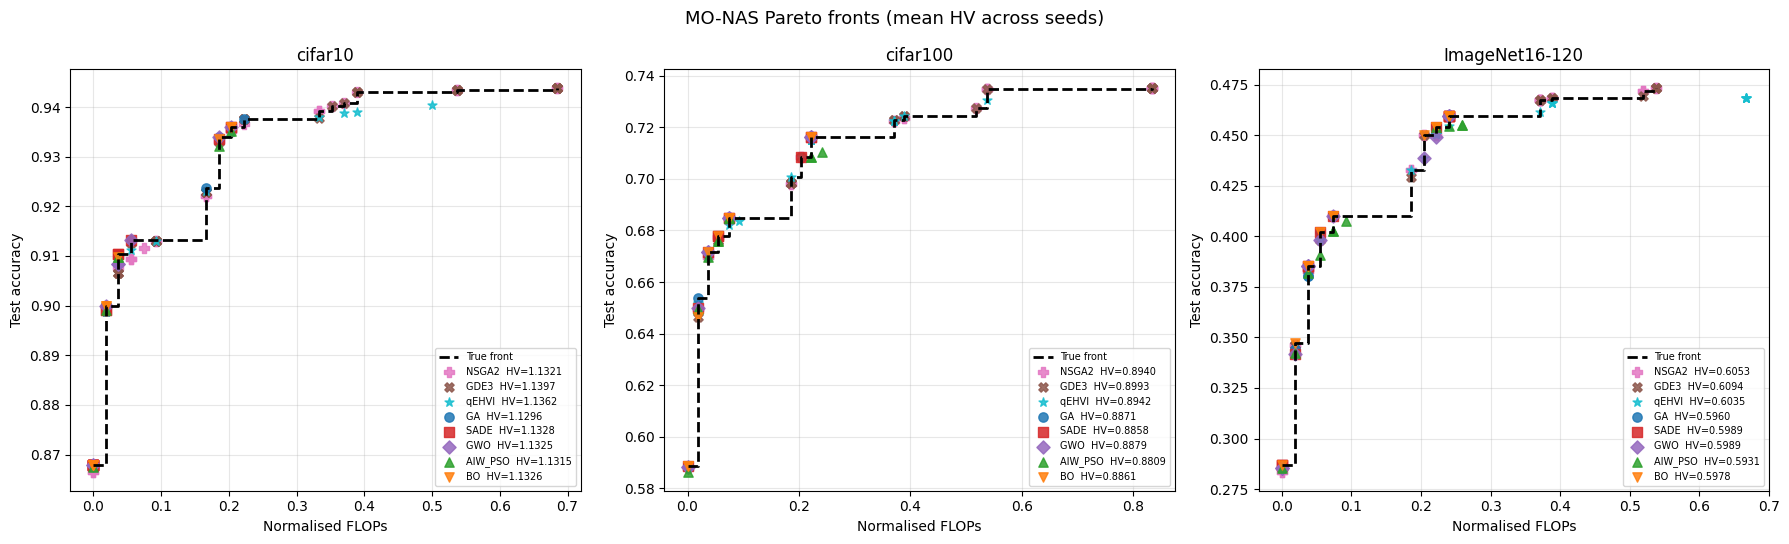

Quick plot saved.


In [10]:
import matplotlib.pyplot as plt
from utils.nas_mo import getNonDominated

ALGO_COLORS = {
    'NSGA2':   '#e377c2',
    'GDE3':    '#8c564b',
    'qEHVI':   '#17becf',
    'GA':      '#1f77b4',
    'SADE':    '#d62728',
    'GWO':     '#9467bd',
    'AIW_PSO': '#2ca02c',
    'BO':      '#ff7f0e',
}
ALGO_MARKERS = {'NSGA2': 'P', 'GDE3': 'X', 'qEHVI': '*', 'GA': 'o',
                'SADE': 's', 'GWO': 'D', 'AIW_PSO': '^', 'BO': 'v'}

# Folder on disk for each algorithm
ALGO_DIRS = {
    'NSGA2':   'nsga2',
    'GDE3':    'gde3',
    'qEHVI':   'qehvi',
    'GA':      'ga',
    'SADE':    'sade',
    'GWO':     'gwo',
    'AIW_PSO': 'aiw_pso',
    'BO':      'bo',
}

# HV means from summary dataframes (used for legend labels)
HV_MEANS = {
    'NSGA2':   df_nsga2,
    'GDE3':    df_gde3,
    'qEHVI':   df_qehvi,
    'GA':      df_ga,
    'SADE':    df_sade,
    'GWO':     df_gwo,
    'AIW_PSO': df_pso,
    'BO':      df_bo,
}


def _load_front_from_dir(run_dir):
    """Load all JSON run files and return the aggregated non-dominated front."""
    all_pts = []
    for jf in sorted(run_dir.glob('*.json')):
        with open(jf) as fh:
            d = json.load(fh)
        if 'pareto_front' in d:   # native (NSGA-II, GDE3, qEHVI): many points per run
            all_pts.extend(d['pareto_front'])
        elif 'best' in d:         # scalarised: one best point per run
            all_pts.append(d['best'])
    if not all_pts:
        return []
    F = np.array([[p['f1'], p['f2']] for p in all_pts])
    nd_idx = getNonDominated(F)
    return sorted([all_pts[i] for i in nd_idx], key=lambda p: p['f2'])


fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
(MO_ROOT / 'figures').mkdir(parents=True, exist_ok=True)

for ax, dataset in zip(axes, DATASETS_USED):
    # True front — dashed step curve
    tf_sorted = sorted(true_fronts[dataset], key=lambda p: p['f2'])
    ax.step([p['f2'] for p in tf_sorted], [p['test_acc'] for p in tf_sorted],
            where='post', color='black', linewidth=2, linestyle='--',
            label='True front', zorder=10)

    for algo, folder in ALGO_DIRS.items():
        run_dir = MO_ROOT / folder / dataset
        if not run_dir.exists():
            continue

        front = _load_front_from_dir(run_dir)
        if not front:
            continue

        df_ds   = HV_MEANS.get(algo)
        if df_ds is not None and not df_ds.empty:
            sub = df_ds[df_ds['dataset'] == dataset]
            hv_mean = sub['hv'].mean() if not sub.empty else float('nan')
        else:
            hv_mean = float('nan')

        ax.scatter(
            [p['f2']       for p in front],   # norm_flops  (x-axis)
            [p['test_acc'] for p in front],   # accuracy    (y-axis)
            color=ALGO_COLORS[algo], marker=ALGO_MARKERS[algo],
            s=45, alpha=0.85, zorder=5,
            label=f'{algo}  HV={hv_mean:.4f}',
        )

    ax.set_xlabel('Normalised FLOPs')
    ax.set_ylabel('Test accuracy')
    ax.set_title(dataset)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

fig.suptitle('MO-NAS Pareto fronts (mean HV across seeds)', fontsize=13)
plt.tight_layout()
fig.savefig(str(MO_ROOT / 'figures' / 'quick_pareto_check.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Quick plot saved.')

## 13. Generate publication figures

Runs the full aggregation script to produce all thesis-ready figures and LaTeX table.

In [14]:
import subprocess, sys

agg_script = ROOT / 'colab' / 'results' / 'MO_NAS' / 'aggregate_mo_nas.py'
if not agg_script.exists():
    agg_script = ROOT.parent / 'code' / 'colab' / 'results' / 'MO_NAS' / 'aggregate_mo_nas.py'

if not agg_script.exists():
    raise FileNotFoundError(f'aggregate_mo_nas.py not found at {agg_script}')

print(f'Running: {agg_script}')
result = subprocess.run(
    [sys.executable, str(agg_script)],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:\n', result.stderr)
else:
    print('aggregate_mo_nas.py finished OK')


Running: c:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\aggregate_mo_nas.py
MO_ROOT = C:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS
OUT_DIR  = C:\Users\ruben\repos\tese-mestrado\code\colab\results\MO_NAS\figures

--- Loading results ---
  GA      /cifar10             27 runs loaded
  GA      /cifar100            27 runs loaded
  GA      /ImageNet16-120      27 runs loaded
  SADE    /cifar10             27 runs loaded
  SADE    /cifar100            27 runs loaded
  SADE    /ImageNet16-120      27 runs loaded
  AIW_PSO /cifar10             27 runs loaded
  AIW_PSO /cifar100            27 runs loaded
  AIW_PSO /ImageNet16-120      27 runs loaded
  GWO     /cifar10             27 runs loaded
  GWO     /cifar100            27 runs loaded
  GWO     /ImageNet16-120      27 runs loaded
  BO      /cifar10             27 runs loaded
  BO      /cifar100            27 runs loaded
  BO      /ImageNet16-120      27 runs loaded
  NSGA2   /cifar10             3 runs loaded